# Gun Violence Twitter Data: Descriptive Analysis
This notebook provides a basic descriptive analysis of the filtered Twitter dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load the final filtered data
df = pd.read_csv('/n/home10/jrochatrindade/gun-violence-twitter-forecasting/data/processed/final_filtered_tweets.csv.gz', compression='gzip', sep='\t')

# Convert timestamp to datetime
if 'tweet_date' in df.columns:
    df['tweet_date'] = pd.to_datetime(df['tweet_date'])

print(f"Total tweets analyzed: {len(df)}")
df.head()

Total tweets analyzed: 1646


,message_id,date,text,tags,tweet_lang,source,place,geom,retweets,tweet_favorites,...,user_favorites,status,user_lang,latitude,longitude,data_source,GPS,spatialerror,tweet_date,matched_incident
0,1529221517451661313,2022-05-24 22:03:15,"🔥 2,000K+ #Google searches 4 Texas school shoo...","Google,Uvalde,Covid,UvaldeCounty",en,"<a href=""https://trendsmetadata.com"" rel=""nofo...","Uvalde, TX",POINT(-99.7858 29.2094),0,0,...,27.0,248084,NaN,29.209400,-99.785800,{3},True,10.000000,2022-05-24 22:03:15,"Uvalde, TX"
1,1529252957216157696,2022-05-25 00:08:11,"Pictured: Salvador Ramos, 18 yr old of Uvalde,...",NaN,en,"<a href=""http://twitter.com/download/iphone"" r...","Uvalde, TX","POLYGON((-99.814935 29.183728,-99.814935 29.24...",0,0,...,49.0,79,NaN,29.212747,-99.779842,{3},False,3738.321595,2022-05-25 00:08:11,"Uvalde, TX"
2,1529255866507186176,2022-05-25 00:19:45,What is so difficult to understand concerning ...,NaN,en,"<a href=""http://instagram.com"" rel=""nofollow"">...","Uvalde, TX",POINT(-99.7896 29.2143),0,0,...,70.0,2140,NaN,29.214300,-99.789600,{3},True,10.000000,2022-05-25 00:19:45,"Uvalde, TX"
3,1529257163633344512,2022-05-25 00:24:54,"At Robb Elementary School, what looks like a h...",UvaldeMassacre,en,"<a href=""http://twitter.com/download/iphone"" r...","Uvalde, TX","POLYGON((-99.814935 29.183728,-99.814935 29.24...",0,0,...,56328.0,24978,NaN,29.212747,-99.779842,{3},False,3738.321595,2022-05-25 00:24:54,"Uvalde, TX"
4,1529261108376309762,2022-05-25 00:40:35,I’m reporting in #Uvalde TX at the civic cente...,Uvalde,en,"<a href=""http://twitter.com/download/iphone"" r...","Uvalde, TX","POLYGON((-99.814935 29.183728,-99.814935 29.24...",0,0,...,22972.0,2208,NaN,29.212747,-99.779842,{3},False,3738.321595,2022-05-25 00:40:35,"Uvalde, TX"


## 1. Tweet Volume by Incident

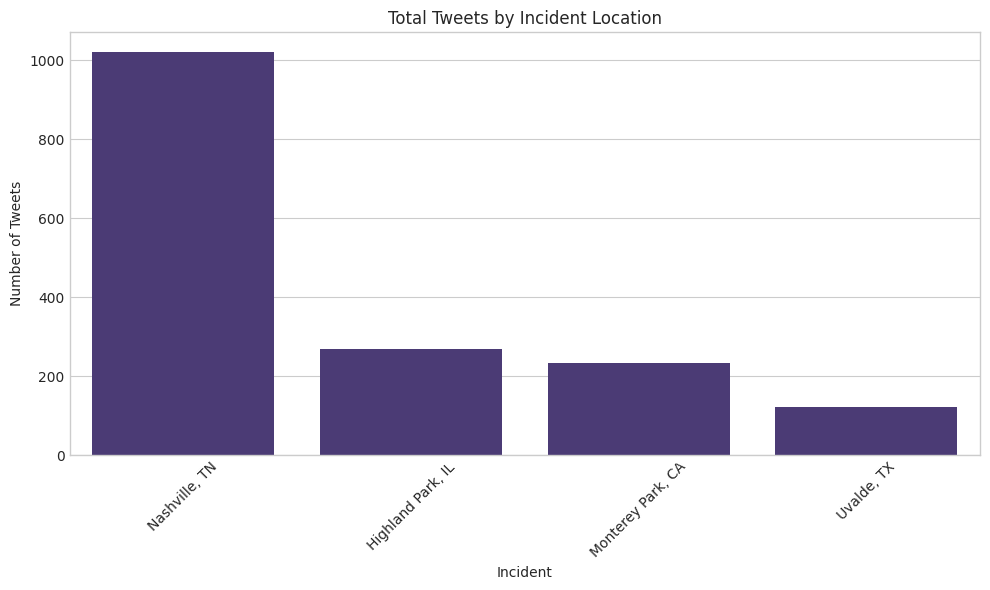

In [3]:
if 'matched_incident' in df.columns:
    incident_counts = df['matched_incident'].value_counts()
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=incident_counts.index, y=incident_counts.values)
    plt.title('Total Tweets by Incident Location')
    plt.ylabel('Number of Tweets')
    plt.xlabel('Incident')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 2. Temporal Analysis
Daily tweet volume surrounding the incident dates.

=== Processing Standardized Temporal Response Curves ===
[COMPUTE] Detecting baseline shock dates (t=0) from data peaks...
  -> Uvalde, TX: Peak volume detected on 2022-05-25 (Setting as t=0)
  -> Highland Park, IL: Peak volume detected on 2022-07-04 (Setting as t=0)
  -> Monterey Park, CA: Peak volume detected on 2023-01-22 (Setting as t=0)
  -> Nashville, TN: Peak volume detected on 2023-03-27 (Setting as t=0)


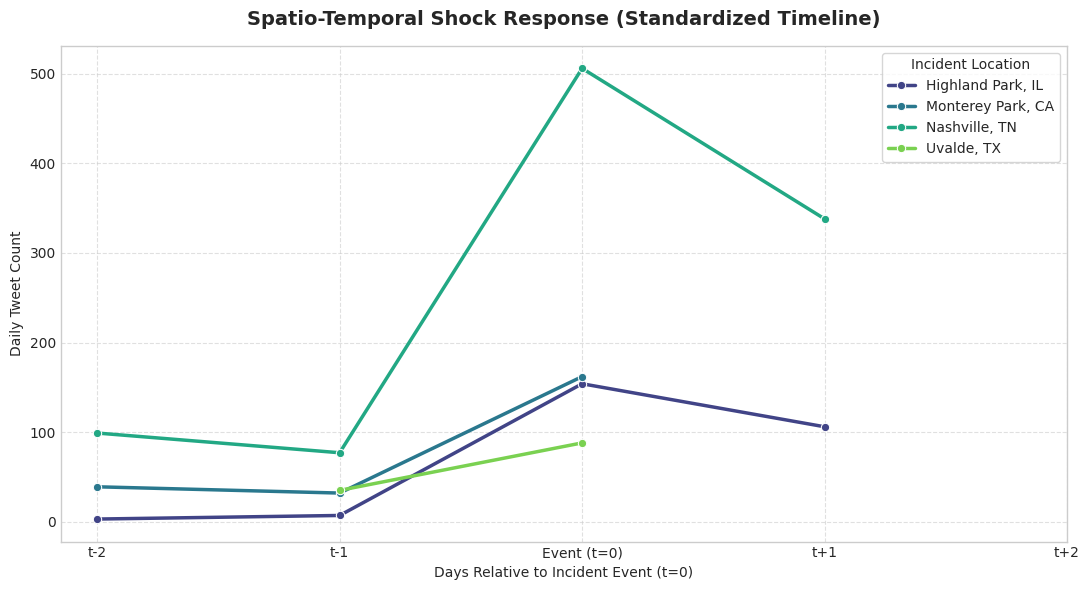

In [4]:
if 'tweet_date' in df.columns and 'matched_incident' in df.columns:
    print("=== Processing Standardized Temporal Response Curves ===")
    
    # 1. Force explicit extraction of date only
    df['date_only'] = pd.to_datetime(df['tweet_date'].dt.date)
    
    # 2. Dynamically find the shock epicenter (t=0) for each city based on peak volume
    print("[COMPUTE] Detecting baseline shock dates (t=0) from data peaks...")
    dynamic_baselines = {}
    for city in df['matched_incident'].dropna().unique():
        city_df = df[df['matched_incident'] == city]
        # Find the date with the absolute maximum number of tweets
        peak_date = city_df['date_only'].value_counts().idxmax()
        dynamic_baselines[city] = pd.to_datetime(peak_date)
        print(f"  -> {city}: Peak volume detected on {peak_date.strftime('%Y-%m-%d')} (Setting as t=0)")
    
    # 3. Map the baselines and calculate relative day delta (t-2 to t+2)
    df['baseline_date'] = df['matched_incident'].map(dynamic_baselines)
    df['relative_day'] = (df['date_only'] - df['baseline_date']).dt.days
    
    # 4. Group by incident and relative day
    relative_counts = df.groupby(['matched_incident', 'relative_day']).size().reset_index(name='tweet_count')
    
    # Filter to ensure we only plot our intended window around the peak
    relative_counts = relative_counts[relative_counts['relative_day'].between(-2, 2)]
    
    # Plotting standard response curves
    plt.figure(figsize=(11, 6))
    sns.lineplot(
        data=relative_counts, 
        x='relative_day', 
        y='tweet_count', 
        hue='matched_incident', 
        marker='o', 
        linewidth=2.5,
        palette='viridis'
    )
    
    plt.title('Spatio-Temporal Shock Response (Standardized Timeline)', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Daily Tweet Count')
    plt.xlabel('Days Relative to Incident Event (t=0)')
    plt.xticks(ticks=[-2, -1, 0, 1, 2], labels=['t-2', 't-1', 'Event (t=0)', 't+1', 't+2'])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Incident Location', frameon=True)
    plt.tight_layout()
    plt.show()